# Who gets federal hazard mitigation money, and for what?
**OpenFEMA Hazard Mitigation Assistance Projects (v4), fiscal years 2015–2024**

Haider Waseem Anwar · Texas A&M Hazard Reduction & Recovery Center

Questions:
1. Do the three mitigation grant streams (post-disaster HMGP, pre-disaster competitive BRIC/PDM, flood-insurance FMA) fund different kinds of projects?
2. Does the size of the federal award differ by project type?
3. Holding program, region and year constant, what drives the size of a federal award?
4. Which states receive the most, and for what?

Data: `HazardMitigationAssistanceProjects.csv` from OpenFEMA, downloaded 3 October 2026. Every number below is computed in this notebook.

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

DATA = "HazardMitigationAssistanceProjects_v4.csv"
OUT = Path("output"); OUT.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

INK, MUTED, RULE = "#16181d", "#5b6270", "#d9dce1"
WATER, CONTOUR = "#2f6f9f", "#9a5b2e"
mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10.5, "axes.edgecolor": RULE,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": INK, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})

raw = pd.read_csv(DATA, low_memory=False)
print(f"{len(raw):,} project records, {raw.shape[1]} fields")

56,410 project records, 33 fields


## 1. Analytical sample and project classes
Kept: fiscal years 2015–2024; HMGP, BRIC, PDM and FMA (BRIC replaced PDM in 2020, so the two are pooled as the pre-disaster competitive stream); projects that were approved or further along; project cost and federal obligation above $1,000. Dropped: planning grants, management costs, advance assistance and feasibility studies, which are not physical mitigation. Each project is classed by its first listed FEMA project-type code.

In [2]:
KEEP_STATUS = {"Closed", "Approved", "Obligated", "Awarded", "Completed"}
df = raw[(raw.programFy.between(2015, 2024)) &
         (raw.programArea.isin(["HMGP", "BRIC", "PDM", "FMA"])) &
         (raw.status.isin(KEEP_STATUS)) &
         (raw.projectAmount > 1000) & (raw.federalShareObligated > 1000)].copy()

df["code"] = df.projectType.str.split(";").str[0].str.extract(r"^(\d+)\.?(\d*)")[0].astype(float)
df["sub"] = df.projectType.str.split(";").str[0].str.extract(r"^\d+\.(\d+)")[0]
first = df.projectType.str.split(";").str[0].str.lower()

def classify(code, text):
    if code in (90, 91, 92, 93, 94, 95, 700, 904, 103) or "plan" in text[:12]:
        return None                                   # planning, management, studies
    if code == 200: return "Acquisition / buyout"
    if code == 202: return "Elevation"
    if code in (204, 403, 404, 405, 500, 501): return "Flood control & drainage"
    if code == 206 or ("wind" in text and code == 205): return "Safe room & wind retrofit"
    if code in (600, 601): return "Generators & warning"
    return "Other structural"

df["project_class"] = [classify(c, t) for c, t in zip(df.code, first)]
df = df.dropna(subset=["project_class"])
df["program"] = df.programArea.replace({"BRIC": "BRIC/PDM", "PDM": "BRIC/PDM"})
df["log_fed"] = np.log(df.federalShareObligated)
df["region_s"] = "R" + df.region.astype(int).astype(str)
print(f"Analytical sample: {len(df):,} projects")
print(df.program.value_counts().to_string())

Analytical sample: 7,781 projects
program
HMGP        6806
FMA          519
BRIC/PDM     456


## 2. Descriptive profile by project class

In [3]:
order = (df.groupby("project_class").federalShareObligated.sum().sort_values(ascending=False).index.tolist())
desc = (df.groupby("project_class").agg(
        projects=("federalShareObligated", "size"),
        federal_total_musd=("federalShareObligated", lambda s: s.sum() / 1e6),
        federal_median_usd=("federalShareObligated", "median"),
        federal_mean_usd=("federalShareObligated", "mean"),
        project_cost_median_usd=("projectAmount", "median"),
        properties_mitigated=("numberOfFinalProperties", "sum"))
        .loc[order])
desc["share_of_federal_pct"] = desc.federal_total_musd / desc.federal_total_musd.sum() * 100
desc.to_csv(OUT / "table1_by_class.csv")
desc.round(1)

,projects,federal_total_musd,federal_median_usd,federal_mean_usd,project_cost_median_usd,properties_mitigated,share_of_federal_pct
project_class,,,,,,,
Other structural,1500,"2,345.700","379,790.500","1,563,778.500","741,192.500",11534,30.000
Acquisition / buyout,1312,"1,575.800","406,128.600","1,201,079.900","530,458.800",8451,20.100
Generators & warning,2681,"1,179.000","119,508.500","439,761.100","154,918.000",52,15.100
Safe room & wind retrofit,1100,"1,014.600","220,992.700","922,377.200","433,389.500",6406,13.000
Flood control & drainage,708,904.700,"392,115.000","1,277,804.300","1,204,957.600",280,11.600
Elevation,480,810.000,"642,287.000","1,687,538.400","820,260.000",4238,10.300


## 3. Do the grant streams fund different kinds of projects?
**Test:** Pearson χ² test of independence, project class × program. **Effect size:** Cramér's V. **Where the difference lies:** adjusted standardized residuals (|r| > 2 marks a cell that departs from independence).

In [4]:
ct = pd.crosstab(df.project_class, df.program).loc[order, ["HMGP", "BRIC/PDM", "FMA"]]
chi2, p, dof, exp = stats.chi2_contingency(ct)
n = ct.values.sum(); k = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
row = ct.sum(axis=1).values[:, None] / n; col = ct.sum(axis=0).values[None, :] / n
adj_resid = (ct.values - exp) / np.sqrt(exp * (1 - row) * (1 - col))
resid = pd.DataFrame(adj_resid, index=ct.index, columns=ct.columns)
print(f"chi2({dof}) = {chi2:,.1f}, p = {p:.2e}, Cramer's V = {cramers_v:.3f}, N = {n:,}")
print(f"Smallest expected count: {exp.min():.1f}")
pd.concat({"observed": ct, "expected": pd.DataFrame(exp, index=ct.index, columns=ct.columns).round(0),
           "adj_residual": resid.round(1)}, axis=1).to_csv(OUT / "table2_crosstab.csv")
display(ct); display(resid.round(1))

chi2(10) = 1,969.8, p = 0.00e+00, Cramer's V = 0.356, N = 7,781
Smallest expected count: 28.1


program,HMGP,BRIC/PDM,FMA
project_class,,,
Other structural,1313,143,44
Acquisition / buyout,995,74,243
Generators & warning,2620,61,0
Safe room & wind retrofit,986,114,0
Flood control & drainage,652,45,11
Elevation,240,19,221


program,HMGP,BRIC/PDM,FMA
project_class,,,
Other structural,0.100,6.700,-6.500
Acquisition / buyout,-14.000,-0.400,18.900
Generators & warning,19.800,-9.800,-17.100
Safe room & wind retrofit,2.300,6.900,-9.600
Flood control & drainage,3.900,0.600,-5.700
Elevation,-25.600,-1.800,35.700


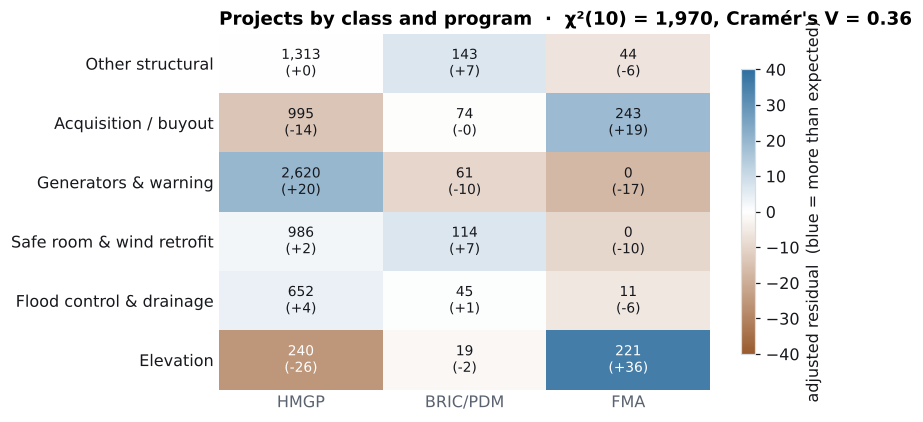

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
lim = np.ceil(np.abs(resid.values).max() / 5) * 5
cmap = mpl.colors.LinearSegmentedColormap.from_list("div", [CONTOUR, "#ffffff", WATER])
im = ax.imshow(resid.values, cmap=cmap, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(3), resid.columns); ax.set_yticks(range(len(resid)), resid.index)
for i in range(resid.shape[0]):
    for j in range(resid.shape[1]):
        v = resid.values[i, j]
        ax.text(j, i, f"{ct.values[i, j]:,}\n({v:+.0f})", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > lim * 0.55 else INK)
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label("adjusted residual  (blue = more than expected)")
ax.set_title(f"Projects by class and program  ·  χ²({dof}) = {chi2:,.0f}, Cramér's V = {cramers_v:.2f}", loc="left")
fig.savefig(OUT / "fig_crosstab.png"); plt.show()

## 4. Does award size differ by project class?
Awards are heavily right-skewed, so tests use log federal share. Levene's test checks equal variances; because it fails, Welch's ANOVA is the main test, with Kruskal–Wallis as a rank-based check and Tukey HSD for pairwise gaps.

In [6]:
groups = [g.log_fed.values for _, g in df.groupby("project_class")]
lev = stats.levene(*groups, center="median")
welch = anova_oneway(df.log_fed, df.project_class, use_var="unequal")
kw = stats.kruskal(*groups)
print(f"Levene (median): W = {lev.statistic:.1f}, p = {lev.pvalue:.2e}")
print(f"Welch ANOVA: F = {welch.statistic:.1f}, p = {welch.pvalue:.2e}")
print(f"Kruskal-Wallis: H = {kw.statistic:.1f}, p = {kw.pvalue:.2e}")
tk = pairwise_tukeyhsd(df.log_fed, df.project_class)
tk_df = pd.DataFrame(tk.summary().data[1:], columns=tk.summary().data[0])
tk_df.to_csv(OUT / "table_tukey.csv", index=False)
tk_df

Levene (median): W = 56.5, p = 6.81e-58
Welch ANOVA: F = 225.5, p = 6.55e-198
Kruskal-Wallis: H = 974.5, p = 1.96e-208


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Acquisition / buyout,Elevation,0.437,0.000,0.193,0.682,True
1,Acquisition / buyout,Flood control & drainage,0.045,0.991,-0.168,0.259,False
2,Acquisition / buyout,Generators & warning,-1.171,0.000,-1.325,-1.016,True
3,Acquisition / buyout,Other structural,-0.052,0.958,-0.225,0.122,False
4,Acquisition / buyout,Safe room & wind retrofit,-0.814,0.000,-1.001,-0.626,True
5,Elevation,Flood control & drainage,-0.392,0.001,-0.663,-0.121,True
6,Elevation,Generators & warning,-1.608,0.000,-1.835,-1.381,True
7,Elevation,Other structural,-0.489,0.000,-0.729,-0.249,True
8,Elevation,Safe room & wind retrofit,-1.251,0.000,-1.502,-1.001,True
9,Flood control & drainage,Generators & warning,-1.216,0.000,-1.410,-1.023,True


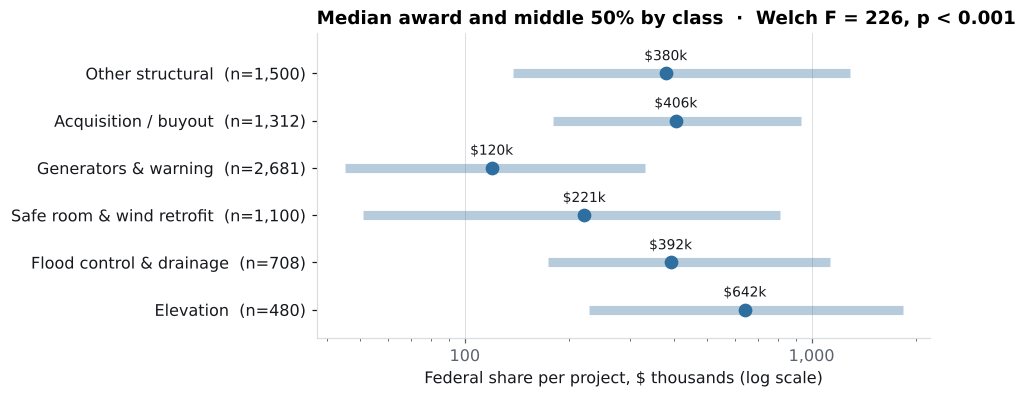

In [7]:
med = df.groupby("project_class").federalShareObligated.median().loc[order] / 1e3
q1 = df.groupby("project_class").federalShareObligated.quantile(.25).loc[order] / 1e3
q3 = df.groupby("project_class").federalShareObligated.quantile(.75).loc[order] / 1e3
nobs = df.project_class.value_counts().loc[order]
fig, ax = plt.subplots(figsize=(7.2, 3.6))
y = np.arange(len(order))[::-1]
ax.hlines(y, q1, q3, color=WATER, lw=6, alpha=.35)
ax.plot(med, y, "o", color=WATER, ms=8)
for yi, m, nn in zip(y, med, nobs):
    ax.text(m, yi + .28, f"${m:,.0f}k", ha="center", fontsize=9, color=INK)
ax.set_yticks(y, [f"{c}  (n={n:,})" for c, n in zip(order, nobs)])
ax.set_ylim(-0.6, len(order) - 0.15)
ax.set_xscale("log"); ax.set_xlabel("Federal share per project, $ thousands (log scale)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title(f"Median award and middle 50% by class  ·  Welch F = {welch.statistic:,.0f}, p < 0.001", loc="left")
ax.grid(axis="x", color=RULE, lw=.6)
fig.savefig(OUT / "fig_award_size.png"); plt.show()

## 5. Regression: what drives the size of a federal award?
OLS on log federal share with project class, program, FEMA region and fiscal-year fixed effects. Reference levels: acquisition/buyout, HMGP, Region 6, FY2015. Cost share is left out on purpose: federal share is cost × cost share, so including it would build the outcome into a predictor.

Diagnostics for the Gauss–Markov (BLUE) conditions: VIF for multicollinearity, Breusch–Pagan for heteroskedasticity, Jarque–Bera for residual normality. Inference uses HC3 robust errors, with state-clustered errors as a robustness check because projects in one state share administration.

In [8]:
f = ("log_fed ~ C(project_class, Treatment('Acquisition / buyout')) + C(program, Treatment('HMGP'))"
     " + C(region_s, Treatment('R6')) + C(programFy)")
ols = smf.ols(f, data=df).fit()
hc3 = smf.ols(f, data=df).fit(cov_type="HC3")
cl = smf.ols(f, data=df).fit(cov_type="cluster", cov_kwds={"groups": df.loc[ols.model.data.row_labels, "stateNumberCode"]})

X = ols.model.exog; names = ols.model.exog_names
vif = pd.Series([variance_inflation_factor(X, i) for i in range(1, X.shape[1])], index=names[1:])
bp = het_breuschpagan(ols.resid, X)
jb = stats.jarque_bera(ols.resid)
print(f"N = {int(ols.nobs):,}, R² = {ols.rsquared:.3f}, adj. R² = {ols.rsquared_adj:.3f}")
print(f"Max VIF (excluding fiscal-year dummies) = {vif[~vif.index.str.contains('programFy')].max():.2f}")
print(f"Breusch-Pagan LM = {bp[0]:,.1f}, p = {bp[1]:.2e}")
print(f"Jarque-Bera = {jb.statistic:,.1f}, p = {jb.pvalue:.2e}, residual skew = {stats.skew(ols.resid):.2f}")

N = 7,781, R² = 0.183, adj. R² = 0.180
Max VIF (excluding fiscal-year dummies) = 2.45
Breusch-Pagan LM = 429.7, p = 2.50e-75
Jarque-Bera = 58.3, p = 2.18e-13, residual skew = -0.07


In [9]:
def clean(n):
    return (n.replace("C(project_class, Treatment('Acquisition / buyout'))[T.", "")
             .replace("C(program, Treatment('HMGP'))[T.", "Program: ")
             .replace("C(region_s, Treatment('R6'))[T.", "Region ").rstrip("]"))
keep = [n for n in hc3.params.index if "programFy" not in n and n != "Intercept"]
reg = pd.DataFrame({"coef": hc3.params[keep], "se_hc3": hc3.bse[keep], "p_hc3": hc3.pvalues[keep],
                    "se_state_cluster": cl.bse[keep], "p_state_cluster": cl.pvalues[keep]})
reg["pct_effect"] = (np.exp(reg.coef) - 1) * 100
ci = hc3.conf_int().loc[keep]
reg["pct_lo"] = (np.exp(ci[0]) - 1) * 100; reg["pct_hi"] = (np.exp(ci[1]) - 1) * 100
reg.index = [clean(i) for i in reg.index]
reg.to_csv(OUT / "table3_regression.csv")
reg.round(3)

,coef,se_hc3,p_hc3,se_state_cluster,p_state_cluster,pct_effect,pct_lo,pct_hi
Elevation,0.138,0.081,0.090,0.115,0.230,14.762,-2.110,34.543
Flood control & drainage,-0.299,0.075,0.000,0.237,0.206,-25.839,-35.933,-14.156
Generators & warning,-1.392,0.053,0.000,0.180,0.000,-75.132,-77.580,-72.417
Other structural,-0.296,0.066,0.000,0.165,0.073,-25.636,-34.699,-15.316
Safe room & wind retrofit,-0.968,0.077,0.000,0.446,0.030,-62.006,-67.304,-55.850
Program: BRIC/PDM,0.674,0.081,0.000,0.196,0.001,96.207,67.443,129.914
Program: FMA,0.294,0.078,0.000,0.170,0.084,34.180,15.248,56.222
Region R1,-0.695,0.088,0.000,0.265,0.009,-50.080,-57.975,-40.703
Region R10,-0.630,0.087,0.000,0.218,0.004,-46.714,-55.097,-36.767
Region R2,-0.222,0.080,0.006,0.238,0.351,-19.916,-31.560,-6.290


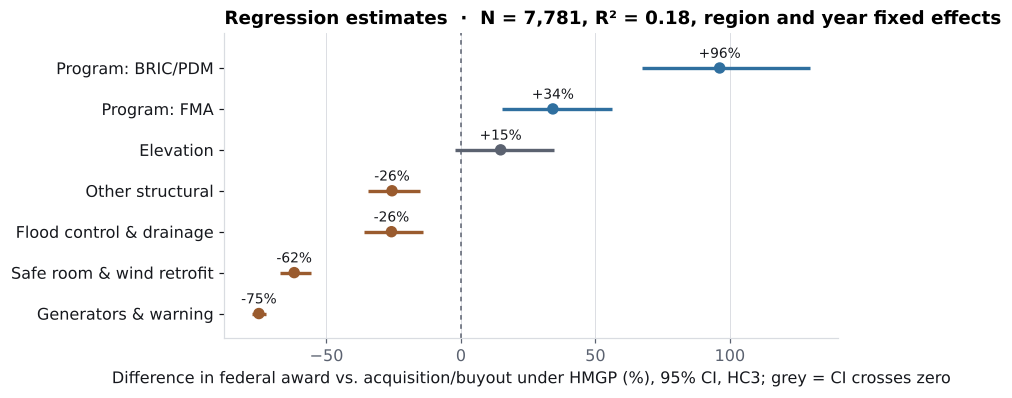

In [10]:
show = reg[~reg.index.str.startswith("Region")].copy()
show = show.sort_values("pct_effect")
fig, ax = plt.subplots(figsize=(7.2, 3.6))
y = np.arange(len(show))
colors = [MUTED if lo < 0 < hi else (WATER if v > 0 else CONTOUR)
          for v, lo, hi in zip(show.pct_effect, show.pct_lo, show.pct_hi)]
ax.hlines(y, show.pct_lo, show.pct_hi, color=colors, lw=2.2)
ax.scatter(show.pct_effect, y, color=colors, s=42, zorder=3)
ax.axvline(0, color=MUTED, lw=1, ls=(0, (3, 3)))
for yi, v in zip(y, show.pct_effect):
    ax.text(v, yi + .25, f"{v:+.0f}%", ha="center", fontsize=9, color=INK)
ax.set_yticks(y, show.index); ax.set_ylim(-0.6, len(show) - 0.15)
ax.set_xlabel("Difference in federal award vs. acquisition/buyout under HMGP (%), 95% CI, HC3; grey = CI crosses zero")
ax.set_title(f"Regression estimates  ·  N = {int(hc3.nobs):,}, R² = {hc3.rsquared:.2f}, region and year fixed effects", loc="left")
ax.grid(axis="x", color=RULE, lw=.6)
fig.savefig(OUT / "fig_regression.png"); plt.show()

## 6. Which states receive the most, and for what?

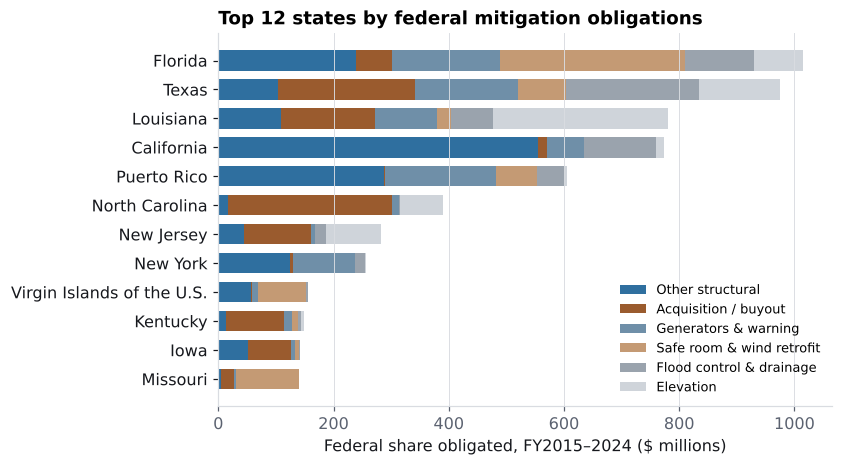

,federal_musd
state,
Florida,"1,014.700"
Texas,975.200
Louisiana,780.900
California,774.100
Puerto Rico,606.000
North Carolina,390.200
New Jersey,281.700
New York,255.700
Virgin Islands of the U.S.,155.100


In [11]:
st = df.pivot_table(index="state", columns="project_class", values="federalShareObligated",
                    aggfunc="sum", fill_value=0) / 1e6
top = st.loc[st.sum(axis=1).sort_values(ascending=False).index[:12], order]
top.to_csv(OUT / "table4_top_states.csv")
pal = [WATER, CONTOUR, "#6f8fa8", "#c49a74", "#9aa3ad", "#cfd4da"]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
left = np.zeros(len(top))
for c, colr in zip(order, pal):
    ax.barh(top.index[::-1], top[c].values[::-1], left=left[::-1], color=colr, label=c, height=.7)
    left = left + top[c].values
ax.set_xlabel("Federal share obligated, FY2015–2024 ($ millions)")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.set_title("Top 12 states by federal mitigation obligations", loc="left")
ax.grid(axis="x", color=RULE, lw=.6)
fig.savefig(OUT / "fig_states.png"); plt.show()
top.sum(axis=1).round(1).rename("federal_musd").to_frame()

## 7. Reading the results
- The χ² test asks whether project mix depends on program; Cramér's V says how strongly.
- Welch's ANOVA asks whether typical award size differs by class without assuming equal spread.
- The regression separates class, program, region and year so each effect is net of the others; HC3 and state-clustered errors keep the inference honest when variance is unequal and projects cluster within states.
- Limits: these are project-level grant records, not outcomes. They show where money went and for what, not whether mitigation reduced later losses. That needs loss data (for example NFIP claims or the National Risk Index) joined at county level.